### Feature Engineering = Deriving new features from existing onces

##### For SpaceDebrisRadar.AI using the primary orbital parameters, we get an easy way to derive such features.
-----

We will derive following features with scientific/mathematical methods

1. Orbit height (h) :
- Describes how high a satellite is above Earth.
- Used to identify orbit type
- Higher orbit = Low drag, more stable, less velocity
- Lower orbit = high drag, less stable, higher velocity

Method to derive -> Using Kepler's 3rd law  
$$
a = \left( \frac{\mu \, T^2}{4 \pi^2} \right)^{\frac{1}{3}}
$$

Where:  
- $a$ = semi-major axis (meters)  
- $\mu = 3.986 \times 10^{14} \, \mathrm{m^3/s^2}$ (Earth’s gravitational parameter)  
- $T$ = orbital period in seconds (computed as $T = \frac{86400}{\text{MEAN\_MOTION}}$)

##### So, we will need to derive first : 1. T (orbital perdiod in second)
----
### 2. Perigee and Apogee :

- **Perigee:** Closest point of the satellite’s orbit relative to Earth’s surface  
- **Apogee:** Farthest point of the satellite’s orbit relative to Earth’s surface  

These two features describe how stretched or circular the orbit is and help define orbital class and stability.

#### Why this correction?
Using the orbital formula $a (1 \pm e)$ gives the distance from **Earth’s center**.  
However, standard catalogs (e.g., SpaceTrack) report perigee/apogee as **altitudes above Earth's surface**.

So we convert orbital radius → altitude by subtracting Earth’s radius.

#### Method to derive (corrected):

1. Compute semi-major axis $a$ from Kepler's 3rd law  
2. Use eccentricity $e$ from the TLE  
3. Compute orbital radii:  
   - $r_{\text{perigee}} = a(1 - e)$  
   - $r_{\text{apogee}} = a(1 + e)$  

4. Convert orbital radii to **altitudes**:  
   - $\text{Perigee Altitude} = r_{\text{perigee}} - R_{\oplus}$  
   - $\text{Apogee Altitude} = r_{\text{apogee}} - R_{\oplus}$  

Where:  
- $a$ = semi-major axis (km)  
- $e$ = eccentricity  
- $R_{\oplus} \approx 6378 \text{ km}$ (Earth’s mean radius)

This ensures that the derived perigee/apogee match standard definitions from satellite catalogs and operational datasets.


----
3. Orbit speed (v) :
- Describes how fast a satellite is moving .
- Nearer the perigee = higher speed
- Nearer the apogee = lower speed

Method to derive -> sing semi-major axis and radius (vis-viva equation)

Formula:

v = v ≈ sqrt(μ / a)

Where:

μ = Earth’s gravitational parameter

a = semi-major axis

----
4. Age since launch (Days) :


- **Definition:** Time elapsed between the satellite’s **launch date** and the **epoch date** of the current observation.
- **Formula (conceptual):**  
  $$\text{Age (days)} = \text{Epoch Date} - \text{Launch Date}$$
- **Why it matters:**  
  - Satellites degrade over time due to **orbital decay**, **space weather**, or **mechanical aging**.  
  - Useful for **anomaly detection** or understanding expected orbital behavior.
- **Units:** Typically **days**, but can also convert to **years** for readability.
- **Prototype use:** Can be added as a **numerical feature** for clustering or ML models.
----
5. Satellite Type

- **Definition:** The **type or sequence of the satellite** within a launch, extracted from the last character of the `OBJECT_ID`.  
- **How it’s extracted:**  
  - `OBJECT_ID` format: `YYYY-NNN[A-Z]`  
    - `YYYY` → launch year  
    - `NNN` → launch number of that year  
    - `[A-Z]` → satellite type / sequence (A = primary payload, B/C... = secondary payloads)  
- **Why it matters:**  
  - Satellites of the same launch can behave differently; primary payloads may have **different orbit characteristics** than secondary or experimental satellites.  
  - Useful as a **categorical feature** for clustering or anomaly detection.  
- **Prototype use:** Can be added as a **categorical feature** to help ML models distinguish satellite roles within the same launch.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Important thorughout this project
%matplotlib inline


In [36]:
df = pd.read_csv('../data/02_cleaned/satellites_cleaned.csv')

In [37]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-11-29T02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,U,900,999,4390,0.000815,8.060000e-06,0.0
1,CALSPHERE 2,1964-063E,2025-11-29T03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,U,902,999,82921,0.000042,3.700000e-07,0.0
2,LCS 1,1965-034C,2025-11-29T03:13:57.846720,9.893094,0.001341,32.1435,292.0260,134.3505,225.8092,0,U,1361,999,19007,0.000093,9.000000e-08,0.0
3,TEMPSAT 1,1965-065E,2025-11-29T03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,U,1512,999,93338,0.000091,5.500000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-11-29T04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,U,1520,999,93599,0.000265,1.470000e-06,0.0


In [38]:
len(df)

13499

#### 1. Let's compute Orbit height (h) in Kilometers

- Compute orbital period in seconds
- It tells that in average, how much time (in seconds) does a satellite takes to orbit around the Earth

In [39]:
df['ORBIT_PERIOD_SEC'] = 86400 / df['MEAN_MOTION']

In [40]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC
0,CALSPHERE 1,1964-063C,2025-11-29T02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,U,900,999,4390,0.000815,8.060000e-06,0.0,6277.520976
1,CALSPHERE 2,1964-063E,2025-11-29T03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,U,902,999,82921,0.000042,3.700000e-07,0.0,6386.370100
2,LCS 1,1965-034C,2025-11-29T03:13:57.846720,9.893094,0.001341,32.1435,292.0260,134.3505,225.8092,0,U,1361,999,19007,0.000093,9.000000e-08,0.0,8733.365167
3,TEMPSAT 1,1965-065E,2025-11-29T03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,U,1512,999,93338,0.000091,5.500000e-07,0.0,6478.798798
4,CALSPHERE 4A,1965-065H,2025-11-29T04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,U,1520,999,93599,0.000265,1.470000e-06,0.0,6465.926220


 - Compute Earth’s gravitational parameter

In [41]:
# Gravitational constant (G) in N m^2/kg^2
G = 6.67430e-11 

# Mass of Earth (M_E) in kg
M_earth = 5.972e24 

# Calculate Earth's gravitational parameter in m^3/s^2
mu_earth_calculated = G * M_earth  # in meters

In [42]:
mu_earth_calculated

398589196000000.0

- Compute Semi major axis for each satelite (in KM)

In [43]:
df['SEMI_MAJOR_AXIS'] = ((mu_earth_calculated * df['ORBIT_PERIOD_SEC'] ** 2 ) / (4*math.pi**2)) **(1/3) / 1000

In [44]:
df['SEMI_MAJOR_AXIS']

0        7354.966693
1        7439.743866
2        9165.925896
3        7511.354469
4        7501.401745
            ...     
13494    6967.646847
13495    6967.182734
13496    6966.696379
13497    6966.477943
13498    6797.204362
Name: SEMI_MAJOR_AXIS, Length: 13499, dtype: float64

- Lastly, subtract semi mejor axis with Earth's radius to get orbital height (h)

In [45]:
df['ORBIT_HEIGHT'] = df['SEMI_MAJOR_AXIS'] -  6371

In [46]:
df['ORBIT_HEIGHT']

0         983.966693
1        1068.743866
2        2794.925896
3        1140.354469
4        1130.401745
            ...     
13494     596.646847
13495     596.182734
13496     595.696379
13497     595.477943
13498     426.204362
Name: ORBIT_HEIGHT, Length: 13499, dtype: float64

In [47]:
df['ORBIT_HEIGHT'].describe()

count    13499.000000
mean      2437.895124
std       7759.365704
min        198.953686
25%        482.311917
50%        546.816079
75%        579.087853
max      91502.980994
Name: ORBIT_HEIGHT, dtype: float64

---
#### Since our project is about Low Earth Orbit, we can now easiy filter those satellites (orbital height >=160 & orbtial height <=2000)

In [48]:
# before row count : 
df.shape

(13499, 20)

In [49]:
df = df[(df['ORBIT_HEIGHT'] >=160) & (df['ORBIT_HEIGHT'] <=2000)]

In [50]:
df.shape

(12696, 20)

----
#### 2. Let's compute Perigee and Apogee

In [51]:
# Perigee altitude = a * (1 - e) - Earth_radius
df['PERIGEE'] = df['SEMI_MAJOR_AXIS'] * (1 - df['ECCENTRICITY']) - 6378

# Apogee altitude = a * (1 + e) - Earth_radius
df['APOGEE'] = df['SEMI_MAJOR_AXIS'] * (1 + df['ECCENTRICITY']) - 6378


In [52]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
0,CALSPHERE 1,1964-063C,2025-11-29T02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,...,999,4390,0.000815,8.060000e-06,0.0,6277.520976,7354.966693,983.966693,957.272299,996.661088
1,CALSPHERE 2,1964-063E,2025-11-29T03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,...,999,82921,0.000042,3.700000e-07,0.0,6386.370100,7439.743866,1068.743866,1046.470816,1077.016916
3,TEMPSAT 1,1965-065E,2025-11-29T03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,...,999,93338,0.000091,5.500000e-07,0.0,6478.798798,7511.354469,1140.354469,1079.682837,1187.026101
4,CALSPHERE 4A,1965-065H,2025-11-29T04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,...,999,93599,0.000265,1.470000e-06,0.0,6465.926220,7501.401745,1130.401745,1072.108660,1174.694830
5,OPS 5712 (P/L 160),1967-053A,2025-11-29T04:49:46.469856,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,0,...,999,3672,0.001379,8.985000e-05,0.0,5862.185654,7026.865500,655.865500,645.476443,652.254557


----
#### 3. Let's compute Orbit speed (v)

In [53]:
# Since we can see that the Eccentricity for LEO satellites is barly big (max 0.1), v ≈ sqrt(μ / a) is enough to calcualte the
# orbital speed (which might be mostly / should be constant enough throughout the orbit for each indivisual satellite)
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
count,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000,12696.0,12696.000000,12696.0,12696.000000,12696.000000,12696.000000,1.269600e+04,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000
mean,15.016121,0.000527,62.071947,172.012014,162.460470,198.671608,0.0,57005.631774,999.0,13469.036232,0.000022,-0.000016,9.410051e-07,5764.626346,6947.155372,576.155372,565.413306,572.897438
std,0.619064,0.002981,20.704118,106.927002,93.703295,93.961922,0.0,7497.754012,0.0,13302.027891,0.005550,0.002286,3.362214e-05,262.671794,207.459527,207.459527,205.656162,211.581620
min,11.826701,0.000004,0.046600,0.002600,0.044700,0.026000,0.0,900.000000,999.0,11.000000,-0.212100,-0.030180,-1.897400e-07,5299.813280,6569.953686,198.953686,165.268804,197.182712
25%,15.025338,0.000123,43.005000,71.780000,87.553775,93.308650,0.0,52929.250000,999.0,4167.750000,0.000034,0.000001,0.000000e+00,5646.338773,6853.302207,482.302207,474.438995,476.189687
50%,15.088437,0.000152,53.160300,170.400500,103.815250,256.050350,0.0,58409.500000,999.0,10709.000000,0.000148,0.000015,0.000000e+00,5726.239328,6917.804092,546.804092,538.673923,540.697382
75%,15.301951,0.000277,86.398700,265.698400,267.256725,272.701750,0.0,63029.250000,999.0,18561.250000,0.000662,0.000174,0.000000e+00,5750.286682,6937.158117,566.158117,558.403215,560.099030
max,16.302461,0.164860,139.339800,359.999800,359.963500,359.990800,0.0,66664.000000,999.0,99986.000000,0.098168,0.044278,2.722200e-03,7305.503056,8137.456497,1766.456497,1745.120740,2877.702467


In [54]:
# Constants
mu_earth = 3.986e5  # km^3/s^2
R_earth = 6371  # km


# Orbital speed (km/s)
df['ORBITAL_SPEED'] = np.sqrt(mu_earth / df['SEMI_MAJOR_AXIS'])

In [55]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-11-29T02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,...,4390,0.000815,8.060000e-06,0.0,6277.520976,7354.966693,983.966693,957.272299,996.661088,7.361703
1,CALSPHERE 2,1964-063E,2025-11-29T03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,...,82921,0.000042,3.700000e-07,0.0,6386.370100,7439.743866,1068.743866,1046.470816,1077.016916,7.319639
3,TEMPSAT 1,1965-065E,2025-11-29T03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,...,93338,0.000091,5.500000e-07,0.0,6478.798798,7511.354469,1140.354469,1079.682837,1187.026101,7.284664
4,CALSPHERE 4A,1965-065H,2025-11-29T04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,...,93599,0.000265,1.470000e-06,0.0,6465.926220,7501.401745,1130.401745,1072.108660,1174.694830,7.289495
5,OPS 5712 (P/L 160),1967-053A,2025-11-29T04:49:46.469856,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,0,...,3672,0.001379,8.985000e-05,0.0,5862.185654,7026.865500,655.865500,645.476443,652.254557,7.531610


In [56]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
count,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000,12696.0,12696.000000,12696.0,12696.000000,12696.000000,12696.000000,1.269600e+04,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000,12696.000000
mean,15.016121,0.000527,62.071947,172.012014,162.460470,198.671608,0.0,57005.631774,999.0,13469.036232,0.000022,-0.000016,9.410051e-07,5764.626346,6947.155372,576.155372,565.413306,572.897438,7.577090
std,0.619064,0.002981,20.704118,106.927002,93.703295,93.961922,0.0,7497.754012,0.0,13302.027891,0.005550,0.002286,3.362214e-05,262.671794,207.459527,207.459527,205.656162,211.581620,0.107584
min,11.826701,0.000004,0.046600,0.002600,0.044700,0.026000,0.0,900.000000,999.0,11.000000,-0.212100,-0.030180,-1.897400e-07,5299.813280,6569.953686,198.953686,165.268804,197.182712,6.998812
25%,15.025338,0.000123,43.005000,71.780000,87.553775,93.308650,0.0,52929.250000,999.0,4167.750000,0.000034,0.000001,0.000000e+00,5646.338773,6853.302207,482.302207,474.438995,476.189687,7.580151
50%,15.088437,0.000152,53.160300,170.400500,103.815250,256.050350,0.0,58409.500000,999.0,10709.000000,0.000148,0.000015,0.000000e+00,5726.239328,6917.804092,546.804092,538.673923,540.697382,7.590747
75%,15.301951,0.000277,86.398700,265.698400,267.256725,272.701750,0.0,63029.250000,999.0,18561.250000,0.000662,0.000174,0.000000e+00,5750.286682,6937.158117,566.158117,558.403215,560.099030,7.626385
max,16.302461,0.164860,139.339800,359.999800,359.963500,359.990800,0.0,66664.000000,999.0,99986.000000,0.098168,0.044278,2.722200e-03,7305.503056,8137.456497,1766.456497,1745.120740,2877.702467,7.789104


In [57]:
df[df['ORBIT_HEIGHT'] == df['ORBIT_HEIGHT'].max()]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
377,GLOBALSTAR M077,2010-054D,2025-11-29T04:00:44.428032,11.826701,0.001762,52.0117,327.6662,307.6684,131.1957,0,...,69775,0.000132,-7.300000e-07,0.0,7305.503056,8137.456497,1766.456497,1745.12074,1773.792254,6.998812


----
#### 4. Let's find approximate age since launch

In [58]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-11-29T02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,...,4390,0.000815,8.060000e-06,0.0,6277.520976,7354.966693,983.966693,957.272299,996.661088,7.361703
1,CALSPHERE 2,1964-063E,2025-11-29T03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,...,82921,0.000042,3.700000e-07,0.0,6386.370100,7439.743866,1068.743866,1046.470816,1077.016916,7.319639
3,TEMPSAT 1,1965-065E,2025-11-29T03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,...,93338,0.000091,5.500000e-07,0.0,6478.798798,7511.354469,1140.354469,1079.682837,1187.026101,7.284664
4,CALSPHERE 4A,1965-065H,2025-11-29T04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,...,93599,0.000265,1.470000e-06,0.0,6465.926220,7501.401745,1130.401745,1072.108660,1174.694830,7.289495
5,OPS 5712 (P/L 160),1967-053A,2025-11-29T04:49:46.469856,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,0,...,3672,0.001379,8.985000e-05,0.0,5862.185654,7026.865500,655.865500,645.476443,652.254557,7.531610


In [59]:
# Convert Epoch to pandas DateTime object
df['EPOCH'] = pd.to_datetime(df['EPOCH'])


df['AGE_SINCE_LAUNCH'] = round(
    df['EPOCH'].dt.year + df['EPOCH'].dt.dayofyear / 365.25 - df['OBJECT_ID'].str.split('-').str[0].astype(int), 3
)

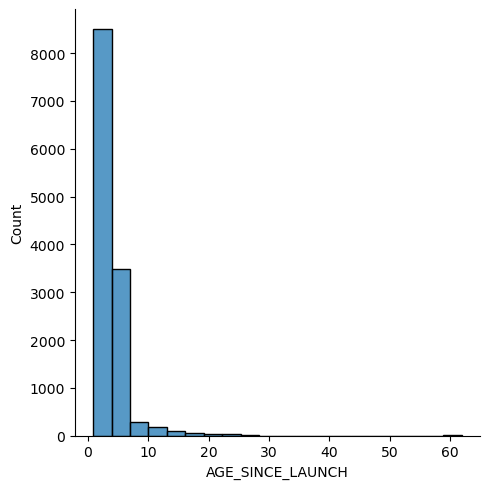

In [60]:
sns.displot(data=df, x = 'AGE_SINCE_LAUNCH', bins = 20)

In [61]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
0,CALSPHERE 1,1964-063C,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,0,...,0.000815,8.060000e-06,0.0,6277.520976,7354.966693,983.966693,957.272299,996.661088,7.361703,61.912
1,CALSPHERE 2,1964-063E,2025-11-29 03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,0,...,0.000042,3.700000e-07,0.0,6386.370100,7439.743866,1068.743866,1046.470816,1077.016916,7.319639,61.912
3,TEMPSAT 1,1965-065E,2025-11-29 03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,0,...,0.000091,5.500000e-07,0.0,6478.798798,7511.354469,1140.354469,1079.682837,1187.026101,7.284664,60.912
4,CALSPHERE 4A,1965-065H,2025-11-29 04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,0,...,0.000265,1.470000e-06,0.0,6465.926220,7501.401745,1130.401745,1072.108660,1174.694830,7.289495,60.912
5,OPS 5712 (P/L 160),1967-053A,2025-11-29 04:49:46.469856,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,0,...,0.001379,8.985000e-05,0.0,5862.185654,7026.865500,655.865500,645.476443,652.254557,7.531610,58.912


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12696 entries, 0 to 13498
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OBJECT_NAME          12696 non-null  object        
 1   OBJECT_ID            12696 non-null  object        
 2   EPOCH                12696 non-null  datetime64[ns]
 3   MEAN_MOTION          12696 non-null  float64       
 4   ECCENTRICITY         12696 non-null  float64       
 5   INCLINATION          12696 non-null  float64       
 6   RA_OF_ASC_NODE       12696 non-null  float64       
 7   ARG_OF_PERICENTER    12696 non-null  float64       
 8   MEAN_ANOMALY         12696 non-null  float64       
 9   EPHEMERIS_TYPE       12696 non-null  int64         
 10  CLASSIFICATION_TYPE  12696 non-null  object        
 11  NORAD_CAT_ID         12696 non-null  int64         
 12  ELEMENT_SET_NO       12696 non-null  int64         
 13  REV_AT_EPOCH         12696 non-null 

----
#### 5. Let's find what type of satellite part it it

In [63]:
# This information is stored as the last digit in the OBJECT_ID column
df['OBJECT_ID']

0        1964-063C
1        1964-063E
3        1965-065E
4        1965-065H
5        1967-053A
           ...    
13494    2025-274K
13495    2025-274L
13496    2025-274M
13497    2025-274N
13498    2025-275A
Name: OBJECT_ID, Length: 12696, dtype: object

In [64]:
# capture anything A-Z as a group
df['SAT_TYPE'] = df['OBJECT_ID'].str.extract(r'([A-Z])$')

In [65]:
df['SAT_TYPE'].value_counts()

SAT_TYPE
A    1206
B     881
C     814
D     716
E     665
F     572
G     538
H     534
J     518
K     503
L     484
M     468
N     456
R     439
Q     438
P     438
V     428
S     421
T     419
U     413
W     405
X     365
Y     318
Z     257
Name: count, dtype: int64

In [66]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
13494,2025-274K,2025-274K,2025-11-29 04:47:55.198752,14.926825,0.001295,97.7370,260.6425,329.8933,30.1541,0,...,0.000032,0.0,5788.236969,6967.646847,596.646847,580.625834,598.667859,7.563548,0.912,K
13495,2025-274L,2025-274L,2025-11-29 04:47:33.582336,14.928316,0.001357,97.7370,260.6431,330.1871,29.8574,0,...,0.000037,0.0,5787.658650,6967.182734,596.182734,579.731751,598.633718,7.563800,0.912,L
13496,2025-274M,2025-274M,2025-11-29 04:47:10.516992,14.929880,0.001422,97.7370,260.6434,330.9976,29.0452,0,...,0.000026,0.0,5787.052635,6966.696379,595.696379,578.790433,598.602324,7.564064,0.912,M
13497,2025-274N,2025-274N,2025-11-29 04:46:59.883744,14.930582,0.001461,97.7378,260.6434,330.6795,29.3604,0,...,0.000016,0.0,5786.780464,6966.477943,595.477943,578.299222,598.656664,7.564183,0.912,N
13498,SOYUZ-MS 28,2025-275A,2025-11-28 22:21:16.003872,15.491774,0.000374,51.6312,210.8341,180.7008,179.3975,0,...,0.000094,0.0,5577.153506,6797.204362,426.204362,416.663567,421.745157,7.657791,0.909,A


---
Correliation : (help up to check if according to physics our features are consistent (except anomalies!))

In [67]:
df.corr(numeric_only=True)

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
MEAN_MOTION,1.000000,-0.130970,-0.368583,-0.053864,0.152225,-0.120924,NaN,0.349489,NaN,-0.310244,-0.006720,-0.016751,0.046241,-0.998328,-0.998836,-0.998836,-0.993045,-0.993518,0.999812,-0.298543
ECCENTRICITY,-0.130970,1.000000,0.095437,-0.000240,-0.012869,0.011134,NaN,-0.151711,NaN,0.157419,0.007484,0.029853,0.002678,0.129920,0.130127,0.130127,0.023628,0.232218,-0.130674,0.191776
INCLINATION,-0.368583,0.095437,1.000000,-0.149341,-0.223812,0.206345,NaN,-0.223122,NaN,0.240835,0.030033,0.058729,0.006489,0.364591,0.365376,0.365376,0.358811,0.367752,-0.367445,0.225734
RA_OF_ASC_NODE,-0.053864,-0.000240,-0.149341,1.000000,-0.036519,0.026977,NaN,-0.029607,NaN,0.028462,0.001167,0.000004,0.011746,0.054040,0.054030,0.054030,0.054356,0.053122,-0.053955,0.026904
ARG_OF_PERICENTER,0.152225,-0.012869,-0.223812,-0.036519,1.000000,-0.936449,NaN,0.155142,NaN,-0.133500,-0.023735,-0.044524,-0.001793,-0.152875,-0.152825,-0.152825,-0.152767,-0.151208,0.152534,-0.104692
MEAN_ANOMALY,-0.120924,0.011134,0.206345,0.026977,-0.936449,1.000000,NaN,-0.128407,NaN,0.106618,-0.005010,-0.051754,0.002760,0.123633,0.123253,0.123253,0.123120,0.122031,-0.121939,0.082707
EPHEMERIS_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NORAD_CAT_ID,0.349489,-0.151711,-0.223122,-0.029607,0.155142,-0.128407,NaN,1.000000,NaN,-0.870421,-0.068686,-0.108562,-0.024146,-0.342139,-0.343382,-0.343382,-0.330222,-0.352409,0.347072,-0.861368
ELEMENT_SET_NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REV_AT_EPOCH,-0.310244,0.157419,0.240835,0.028462,-0.133500,0.106618,NaN,-0.870421,NaN,1.000000,0.040133,0.062433,0.020402,0.302570,0.303841,0.303841,0.289676,0.314280,-0.307679,0.766070


----
###  Remove irrelevent features
- We will now remove those features that will NOT be used in any of the ML models AND are not relevant to our task, that are :
         
1. OBJECT_ID            
2. EPHEMERIS_TYPE   (all have just a single value : 11990)    
3. CLASSIFICATION_TYPE (all have just a single value : U)
4. ELEMENT_SET_NO  (unique identifier)


In [68]:
df = df.drop(columns=['OBJECT_ID',  'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE',  'ELEMENT_SET_NO'])

#### Save the featured data

In [69]:
df.to_csv('../data/03_engineered/satellites_engineered.csv', index=False)

In [70]:
df.head()

,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
0,CALSPHERE 1,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,900,4390,...,8.060000e-06,0.0,6277.520976,7354.966693,983.966693,957.272299,996.661088,7.361703,61.912,C
1,CALSPHERE 2,2025-11-29 03:05:54.157920,13.528812,0.002053,90.2363,71.0754,88.8358,28.0961,902,82921,...,3.700000e-07,0.0,6386.370100,7439.743866,1068.743866,1046.470816,1077.016916,7.319639,61.912,E
3,TEMPSAT 1,2025-11-29 03:03:30.714048,13.335805,0.007145,89.9891,212.6810,90.4072,62.5157,1512,93338,...,5.500000e-07,0.0,6478.798798,7511.354469,1140.354469,1079.682837,1187.026101,7.284664,60.912,E
4,CALSPHERE 4A,2025-11-29 04:04:06.381120,13.362355,0.006838,89.9087,124.3593,308.8371,226.1500,1520,93599,...,1.470000e-06,0.0,6465.926220,7501.401745,1130.401745,1072.108660,1174.694830,7.289495,60.912,H
5,OPS 5712 (P/L 160),2025-11-29 04:49:46.469856,14.738530,0.000482,69.9174,167.1531,291.9090,68.1543,2826,3672,...,8.985000e-05,0.0,5862.185654,7026.865500,655.865500,645.476443,652.254557,7.531610,58.912,A


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12696 entries, 0 to 13498
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OBJECT_NAME        12696 non-null  object        
 1   EPOCH              12696 non-null  datetime64[ns]
 2   MEAN_MOTION        12696 non-null  float64       
 3   ECCENTRICITY       12696 non-null  float64       
 4   INCLINATION        12696 non-null  float64       
 5   RA_OF_ASC_NODE     12696 non-null  float64       
 6   ARG_OF_PERICENTER  12696 non-null  float64       
 7   MEAN_ANOMALY       12696 non-null  float64       
 8   NORAD_CAT_ID       12696 non-null  int64         
 9   REV_AT_EPOCH       12696 non-null  int64         
 10  BSTAR              12696 non-null  float64       
 11  MEAN_MOTION_DOT    12696 non-null  float64       
 12  MEAN_MOTION_DDOT   12696 non-null  float64       
 13  ORBIT_PERIOD_SEC   12696 non-null  float64       
 14  SEMI_MAJOR_